In [4]:
# MohammedOthman1221175.ipynb

# T1: Loading and Initial Exploration
# Load the dataset into a pandas DataFrame.
# Display :
# 1- The first 6 rows 
# 2- The last 6 rows. 
# Show the shape of the dataset (number of rows and columns).
# Generate descriptive statistics for numerical columns (e.g., Rating, Reviews, Installs) 
#  with interpretation.

#  Import libraries as we need 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset : here just upload the file into my Jupyter environment.
df = pd.read_csv("googleplaystore.csv")

# Display the First 6 Rows
print("- First 6 rows:")
display(df.head(6))

# Display the Last 6 Rows
print("\n- Last 6 rows:")
display(df.tail(6))

# Show the shape of the dataset (number of rows and columns). 
print("\n- Shape of the dataset (rows, columns) :")
rows = df.loc[:, :].shape[0]     # All rows
cols = df.loc[:, :].shape[1]     # All columns
print(f"Rows: {rows}, Columns: {cols}")


#  Descriptive Statistics
# We focus on Rating and Reviews columns only.
# describe() only works on numeric columns and Installs treated as a string (object) column
# needs to be cleaned and converted to numeric format before it can be statistically described

# The describe() function gives us :
# - Mean
# - standard deviation
# - Min/Max
# - 25%,50%,75% of data

print("\n- Descriptive statistics for Rating and Reviews:")
display(df[['Rating', 'Reviews']].describe())

- First 6 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up



- Last 6 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device



- Shape of the dataset (rows, columns) :
Rows: 10841, Columns: 13

- Descriptive statistics for Rating and Reviews:


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [13]:
# MohammedOthman1221175.ipynb

# T2: Data Cleaning
# - Print the data types of all columns and check the ability to have null values.
# - Drop rows where Type (Free/Paid) is missing
# - For the Rating column, fill missing values with the median rating of the same app 
# category. Explain why you chose the median. 

# - Convert the Installs column to a numeric type (remove commas and "+", e.g., 
# "1,000,000+" → 1000000).

# - Convert the Price column to a numeric type ($0.99 → 0.99). 

# Reload
df = pd.read_csv("googleplaystore.csv")

# Raw values before cleaning
print("\n Raw 'Installs' values (first 10):")
print(df['Installs'].head(10))

print("\n Raw 'Price' values (first 10):")
print(df['Price'].head(10))

# Summary table before cleaning
summary_before = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum().values
})
print("\n Initial Summary Table:")
display(summary_before)

# Drop rows where 'Type' is missing
print("\n- Dropping rows with missing 'Type'...")
df = df.dropna(subset=['Type'])

#  Fill missing Rating values with median per Category
#  The median is more robust to outliers than the mean, especially with skewed data
print("\n- Filling missing Rating values with median per Category")
df['Rating'] = df.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))

# Clean Installs column and convert to numeric
print("\n- Converting 'Installs' to numeric...")
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean 'Price' column and convert to numeric
print("\n- Converting 'Price' to numeric...")
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Summary table after cleaning
summary_after = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum().values
})

#  Combined comparison table
comparison = pd.DataFrame({
    'Column': df.columns,
    'Before Type': summary_before['Data Type'],
    'After Type': summary_after['Data Type'],
    'Before Nulls': summary_before['Missing Values'],
    'After Nulls': summary_after['Missing Values']
})

print("\n Data Cleaning Comparison Table:")
display(comparison)

print("\n Cleaned 'Installs' values (first 10):")
print(df['Installs'].head(10))

print("\n Cleaned 'Price' values (first 10):")
print(df['Price'].head(10))

# so here is the number of apps with prce zero and non zero values 
print(" Number of apps with price = 0.0:", (df['Price'] == 0.0).sum())
print(" Number of apps with price > 0.0:", (df['Price'] > 0.0).sum())

# To insure that i convert the price correctly 
print("\n To insure that i convert the price correctly:")
display(df[df['Price'] > 0][['App', 'Price']].head(10))



 Raw 'Installs' values (first 10):
0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
5        50,000+
6        50,000+
7     1,000,000+
8     1,000,000+
9        10,000+
Name: Installs, dtype: object

 Raw 'Price' values (first 10):
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Price, dtype: object

 Initial Summary Table:


,Column,Data Type,Missing Values
App,App,object,0
Category,Category,object,0
Rating,Rating,float64,1474
Reviews,Reviews,object,0
Size,Size,object,0
Installs,Installs,object,0
Type,Type,object,1
Price,Price,object,0
Content Rating,Content Rating,object,1
Genres,Genres,object,0



- Dropping rows with missing 'Type'...

- Filling missing Rating values with median per Category

- Converting 'Installs' to numeric...

- Converting 'Price' to numeric...

 Data Cleaning Comparison Table:


,Column,Before Type,After Type,Before Nulls,After Nulls
App,App,object,object,0,0
Category,Category,object,object,0,0
Rating,Rating,float64,float64,1474,0
Reviews,Reviews,object,object,0,0
Size,Size,object,object,0,0
Installs,Installs,object,float64,0,1
Type,Type,object,object,1,0
Price,Price,object,float64,0,1
Content Rating,Content Rating,object,object,1,1
Genres,Genres,object,object,0,0



 Cleaned 'Installs' values (first 10):
0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
5       50000.0
6       50000.0
7     1000000.0
8     1000000.0
9       10000.0
Name: Installs, dtype: float64

 Cleaned 'Price' values (first 10):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Price, dtype: float64
 Number of apps with price = 0.0: 10039
 Number of apps with price > 0.0: 800

 To insure that i convert the price correctly:


,App,Price
234,TurboScan: scan documents and receipts in PDF,4.99
235,Tiny Scanner Pro: PDF Doc Scan,4.99
290,TurboScan: scan documents and receipts in PDF,4.99
291,Tiny Scanner Pro: PDF Doc Scan,4.99
427,Puffin Browser Pro,3.99
476,"Moco+ - Chat, Meet People",3.99
477,Calculator,6.99
478,Truth or Dare Pro,1.49
479,"Private Dating, Hide App- Blue for PrivacyHider",2.99
480,Ad Blocker for SayHi,3.99


In [23]:
# MohammedOthman1221175.ipynb

# T3: Data Filtering
# -  Create a new DataFrame containing only free apps (Type = Free).
# - Filter apps with a rating greater than 4.5 and more than 1 million installs.
# - List the top 3 most installed apps in the "Education" category. Hint (case sensitive) 

# Filter free apps only
print("- Filtering free apps...")
free_apps = df[df['Type'] == 'Free']
print(f" Total free apps: {len(free_apps)}")

#  Filter apps with Rating > 4.5 and Installs > 1 million
print("\n- Filtering high-rated popular apps (Rating > 4.5 and Installs > 1 million)...")
popular_high_rated = free_apps[
    (free_apps['Rating'] > 4.5) & (free_apps['Installs'] > 1_000_000)
]
print(f" Total apps after flitering : {len(popular_high_rated)}")

#  Preview filtered apps
print("\n Preview of high-rated popular apps:")
display(popular_high_rated[['App', 'Rating', 'Installs', 'Category']].head(5))

#  Filter 'Education' category apps (case-insensitive match)
print("\n- Filtering apps in the 'Education' category (case-insensitive)...")
education_apps = df[df['Category'].str.lower() == 'education']
print(f" Total apps in 'Education': {len(education_apps)}")

# Sort and get top 3 by Installs
top_3_edu_apps = education_apps.sort_values(by='Installs', ascending=False).head(3)

#  Display the top 3 most installed education apps
print("\n- Top 3 most installed 'Education' apps (case-insensitive):")
display(top_3_edu_apps[['App', 'Installs', 'Rating']])
# here the same app apears 3 times (top 3) so if i need to fix this problem i will remove the duplicates 
education_apps = df[df['Category'].str.lower() == 'education']

# Remove duplicate apps by the name of the app and get the top 3 installs
education_apps_unique = education_apps.drop_duplicates(subset='App')
top_3_edu_apps = education_apps_unique.sort_values(by='Installs', ascending=False).head(3)

# Display result after i remove duplicates and get the top 3 apps 
print("\n- Top 3 most installed 'Education' apps (case-insensitive):")
display(top_3_edu_apps[['App', 'Installs', 'Rating']])



- Filtering free apps...
 Total free apps: 10039

- Filtering high-rated popular apps (Rating > 4.5 and Installs > 1 million)...
 Total apps after flitering : 470

 Preview of high-rated popular apps:


,App,Rating,Installs,Category
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,5000000.0,ART_AND_DESIGN
19,ibis Paint X,4.6,10000000.0,ART_AND_DESIGN
45,"Canva: Poster, banner, card maker & graphic de...",4.7,10000000.0,ART_AND_DESIGN
70,Fines of the State Traffic Safety Inspectorate...,4.8,5000000.0,AUTO_AND_VEHICLES
139,Wattpad 📖 Free Books,4.6,100000000.0,BOOKS_AND_REFERENCE



- Filtering apps in the 'Education' category (case-insensitive)...
 Total apps in 'Education': 156

- Top 3 most installed 'Education' apps (case-insensitive):


,App,Installs,Rating
699,Duolingo: Learn Languages Free,100000000.0,4.7
826,Duolingo: Learn Languages Free,100000000.0,4.7
799,Duolingo: Learn Languages Free,100000000.0,4.7



- Top 3 most installed 'Education' apps (case-insensitive):


,App,Installs,Rating
699,Duolingo: Learn Languages Free,100000000.0,4.7
825,ClassDojo,10000000.0,4.4
718,Math Tricks,10000000.0,4.5


In [19]:
# MohammedOthman1221175.ipynb

# T4: Grouping and Aggregation
# - Group the data by Category and calculate the average rating for each category.
# - Which category has the lowest and highest average rating?
# - Group the data by Content Rating (e.g., Everyone, Teen) and calculate each group's 
# median and sum number of installs.

# Group by Category and calculate average rating
print("- Average Rating by Category:")
category_avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
display(category_avg_rating)

#  Highest and lowest rated categories
highest_rating_category = category_avg_rating.idxmax()
lowest_rating_category = category_avg_rating.idxmin()
highest_value = category_avg_rating.max()
lowest_value = category_avg_rating.min()

print(f"\n- Category with highest average rating: {highest_rating_category} ({highest_value:.2f})")
print(f"-Category with lowest average rating: {lowest_rating_category} ({lowest_value:.2f})")

#  Group by Content Rating and calculate median + sum of installs
print("\n- Median and Total Installs by Content Rating:")
content_rating_stats = df.groupby('Content Rating')['Installs'].agg(['median', 'sum'])
display(content_rating_stats)

# The "Category" value '1.9' with average rating 19.0 appears to be a data entry error.
# It likely came from a misaligned row where the rating value shifted into the Category column.
# the solution of this error is to drop  (1.9) and ignore it 


- Average Rating by Category:


Category
1.9                    19.000000
EVENTS                  4.454688
EDUCATION               4.389103
BOOKS_AND_REFERENCE     4.381385
ART_AND_DESIGN          4.360000
PERSONALIZATION         4.348724
PARENTING               4.316667
HEALTH_AND_FITNESS      4.305865
GAME                    4.290997
BEAUTY                  4.283019
SHOPPING                4.263077
SOCIAL                  4.261017
WEATHER                 4.248780
SPORTS                  4.236458
PRODUCTIVITY            4.226651
MEDICAL                 4.216199
HOUSE_AND_HOME          4.211364
AUTO_AND_VEHICLES       4.205882
FAMILY                  4.204515
PHOTOGRAPHY             4.197910
FOOD_AND_DRINK          4.185827
LIBRARIES_AND_DEMO      4.183529
BUSINESS                4.182391
COMMUNICATION           4.180103
COMICS                  4.163333
FINANCE                 4.151639
NEWS_AND_MAGAZINES      4.144170
TRAVEL_AND_LOCAL        4.132946
ENTERTAINMENT           4.126174
LIFESTYLE               4.113613
V


- Category with highest average rating: 1.9 (19.00)
-Category with lowest average rating: DATING (3.99)

- Median and Total Installs by Content Rating:


,median,sum
Content Rating,,
Adults only 18+,500000.0,2.000000e+06
Everyone,100000.0,1.141567e+11
Everyone 10+,1000000.0,1.323388e+10
Mature 17+,500000.0,5.524491e+09
Teen,1000000.0,3.471635e+10
Unrated,25250.0,5.050000e+04



- Second highest average rating (after cleaning): EDUCATION (4.39)


In [20]:
# MohammedOthman1221175.ipynb

# T5:  New Column Creation 
# - Create a new column, Revenue Estimate for paid apps, by multiplying Price (convert to 
# numeric) by Installs.

#  Filter only paid apps (safe version using .copy())
print("- Filtering paid apps...")
paid_apps = df[df['Type'] == 'Paid'].copy()
print(f"- Total paid apps: {len(paid_apps)}")

# Create 'Revenue Estimate' column
print("\n- Creating 'Revenue Estimate' column...")
paid_apps['Revenue Estimate'] = paid_apps['Price'] * paid_apps['Installs']

# Preview top apps by revenue
top_revenue_apps = paid_apps.sort_values(by='Revenue Estimate', ascending=False).head(5)

print("\n- Top 5 Paid Apps by Revenue Estimate:")
display(top_revenue_apps[['App', 'Price', 'Installs', 'Revenue Estimate']])



- Filtering paid apps...
- Total paid apps: 800

- Creating 'Revenue Estimate' column...

- Top 5 Paid Apps by Revenue Estimate:


,App,Price,Installs,Revenue Estimate
4347,Minecraft,6.99,10000000.0,69900000.0
2241,Minecraft,6.99,10000000.0,69900000.0
5351,I am rich,399.99,100000.0,39999000.0
5356,I Am Rich Premium,399.99,50000.0,19999500.0
4034,Hitman Sniper,0.99,10000000.0,9900000.0


- Creating histogram of app ratings...


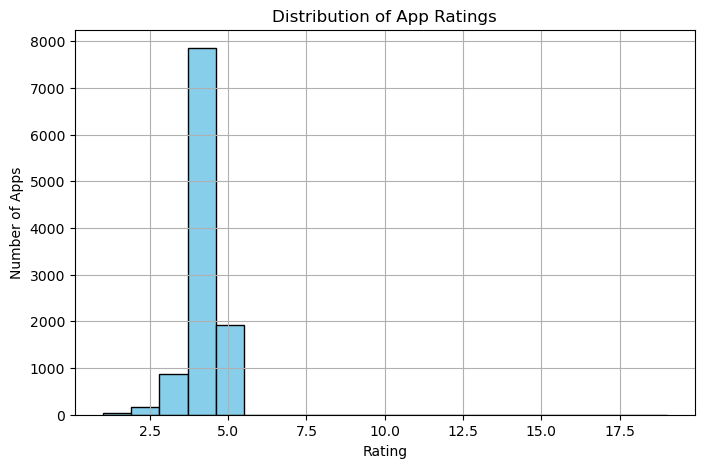


- Creating bar plot of top 10 most common categories...


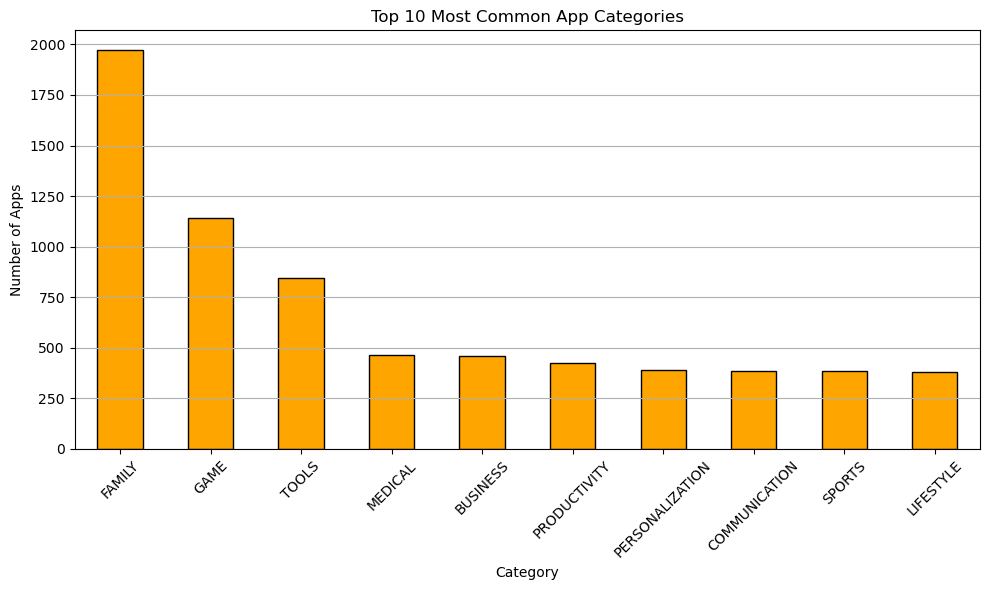

In [21]:
# MohammedOthman1221175.ipynb

# T6: Visualization
# - Use matplotlib to create a histogram of app ratings.
# - Create a bar plot showing the top 10 most common app categories. 

import matplotlib.pyplot as plt

# Histogram of Ratings
print("- Creating histogram of app ratings...")
plt.figure(figsize=(8, 5))
plt.hist(df['Rating'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.grid(True)
plt.show()

# Bar plot of Top 10 Most Common App Categories
print("\n- Creating bar plot of top 10 most common categories...")
top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 10 Most Common App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
